# Notebook 04 — Food Security Classification

**Objective:** Predict IPC (Integrated Food Security Phase Classification) phase per county using NASA (National Aeronautics and Space Administration) POWER weather features.

**This is the core ML (Machine Learning) model of the project.** It automates what FEWS NET (Famine Early Warning Systems Network) analysts do manually — using NASA rainfall and temperature data to classify counties into food security phases.

**Models trained:**
1. Rule-based threshold classifier (baseline)
2. Logistic Regression (intermediate baseline)
3. XGBoost (Extreme Gradient Boosting) classifier (primary model)

**Target variable:** IPC phase (1=Minimal, 2=Stressed, 3=Crisis)  
**Features:** NASA weather aggregates — SPI-3 (Standardised Precipitation Index), rainfall, temperature, dry days, humidity, solar radiation

In [1]:
import sys
!{sys.executable} -m pip install xgboost shap

  Using cached xgboost-2.1.4-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-2.1.4-py3-none-win_amd64.whl (124.9 MB)


In [1]:
import os
project_root = r"C:\Users\HomePC\Desktop\kenya-smart-agriculture"
os.chdir(project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)
import xgboost as xgb
import shap

os.makedirs("models/saved", exist_ok=True)
os.makedirs("figures", exist_ok=True)

print("Libraries loaded ✅")
print(f"XGBoost (Extreme Gradient Boosting) version : {xgb.__version__}")

Libraries loaded ✅
XGBoost (Extreme Gradient Boosting) version : 2.1.4


## Step 1 — Load the Master Dataset

In [2]:
# Load master dataset built in Notebook 02
master = pd.read_csv("data/processed/master_dataset.csv")
ipc    = pd.read_csv("data/processed/ipc_county.csv")

print(f"Master dataset shape : {master.shape}")
print(f"IPC (Integrated Food Security Phase Classification) county shape : {ipc.shape}")
print()
print("IPC phase distribution in master dataset:")
print(master["ipc_phase"].value_counts().sort_index().to_string())
print()
print("IPC phase labels:")
phase_labels = {1: "Minimal", 2: "Stressed", 3: "Crisis"}
for phase, count in master["ipc_phase"].value_counts().sort_index().items():
    pct = count / len(master) * 100
    print(f"  Phase {phase} ({phase_labels[phase]}) : {count:,} rows ({pct:.1f}%)")

Master dataset shape : (13464, 23)
IPC (Integrated Food Security Phase Classification) county shape : (47, 7)

IPC phase distribution in master dataset:
ipc_phase
1    7416
2    2592
3    3456

IPC phase labels:
  Phase 1 (Minimal) : 7,416 rows (55.1%)
  Phase 2 (Stressed) : 2,592 rows (19.3%)
  Phase 3 (Crisis) : 3,456 rows (25.7%)


## Step 2 — Feature Selection

Select NASA (National Aeronautics and Space Administration) weather features that will be used to predict IPC (Integrated Food Security Phase Classification) phase.

In [3]:
# Define features and target
FEATURES = [
    "total_rainfall",      # Monthly total precipitation (mm)
    "mean_temp",           # Mean temperature at 2m (°C)
    "max_temp",            # Maximum temperature (°C)
    "mean_humidity",       # Relative humidity (%)
    "mean_solar",          # Solar radiation (MJ/m²/day)
    "dry_days",            # Days with rainfall < 1mm
    "spi_3",               # SPI-3 (Standardised Precipitation Index — 3 month)
    "temp_range",          # Temperature range (max - min)
    "drought_flag",        # Binary drought indicator (SPI-3 < -1.0)
    "is_long_rains",       # MAM (March-April-May) season flag
    "is_short_rains",      # OND (October-November-December) season flag
]

TARGET = "ipc_phase"

# Check which features are available
available = [f for f in FEATURES if f in master.columns]
missing   = [f for f in FEATURES if f not in master.columns]

print(f"Features available : {len(available)}")
print(f"Features missing   : {missing if missing else 'None'}")
print()
print("Feature summary:")
print(master[available].describe().round(2).to_string())

Features available : 11
Features missing   : None

Feature summary:
       total_rainfall  mean_temp  max_temp  mean_humidity  mean_solar  dry_days     spi_3  temp_range  drought_flag  is_long_rains  is_short_rains
count        13464.00   13464.00  13464.00       13464.00    13464.00  13464.00  13417.00    13464.00      13464.00       13464.00        13464.00
mean            93.90      21.80     27.98          68.21       21.15     14.93      0.02       11.23          0.47           0.25            0.25
std             89.88       3.81      3.96          10.41        2.29      8.86      0.86        2.69          0.50           0.43            0.43
min              0.00      13.08     18.11          28.26       13.08      0.00     -1.15        2.30          0.00           0.00            0.00
25%             29.12      19.15     25.06          61.67       19.70      7.00     -0.78        9.55          0.00           0.00            0.00
50%             69.32      21.14     27.57        

## Step 3 — Prepare Train/Test Split

In [4]:
# Prepare data — drop rows with missing target or features
df = master.dropna(subset=[TARGET] + available).copy()
df[available] = df[available].fillna(df[available].median())

X = df[available]
y = df[TARGET].astype(int)

print(f"Total rows for modelling : {len(df):,}")
print(f"Features used            : {len(available)}")
print(f"Target classes           : {sorted(y.unique())}")
print()

# Stratified train/test split — preserves class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set  : {X_train.shape[0]:,} rows")
print(f"Test set      : {X_test.shape[0]:,} rows")
print()
print("Class distribution in training set:")
for phase, count in y_train.value_counts().sort_index().items():
    print(f"  Phase {phase} ({phase_labels[phase]}) : {count:,}")

Total rows for modelling : 13,417
Features used            : 11
Target classes           : [np.int64(1), np.int64(2), np.int64(3)]

Training set  : 10,733 rows
Test set      : 2,684 rows

Class distribution in training set:
  Phase 1 (Minimal) : 5,912
  Phase 2 (Stressed) : 2,066
  Phase 3 (Crisis) : 2,755


## Step 4 — Baseline Model (Rule-Based Threshold)

A simple rule: if SPI-3 (Standardised Precipitation Index) is below -1.0, classify as Crisis. This is what FEWS NET (Famine Early Warning Systems Network) analysts do informally.

In [5]:
# Rule-based baseline — no training required
def rule_based_predict(X):
    preds = []
    for _, row in X.iterrows():
        spi = row.get("spi_3", 0)
        if pd.isna(spi):
            spi = 0
        if spi < -1.0:
            preds.append(3)   # Crisis
        elif spi < 0:
            preds.append(2)   # Stressed
        else:
            preds.append(1)   # Minimal
    return preds

y_rule = rule_based_predict(X_test)
rule_f1  = f1_score(y_test, y_rule, average="weighted")
rule_acc = accuracy_score(y_test, y_rule)

print("=" * 50)
print("BASELINE — Rule-Based Threshold Classifier")
print("=" * 50)
print(f"Weighted F1 (F1 Score weighted by class)  : {rule_f1:.4f}")
print(f"Accuracy                                  : {rule_acc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_rule,
      target_names=["Phase 1 Minimal", "Phase 2 Stressed", "Phase 3 Crisis"]))

BASELINE — Rule-Based Threshold Classifier
Weighted F1 (F1 Score weighted by class)  : 0.3822
Accuracy                                  : 0.3793

Classification Report:
                  precision    recall  f1-score   support

 Phase 1 Minimal       0.56      0.49      0.52      1478
Phase 2 Stressed       0.20      0.40      0.27       517
  Phase 3 Crisis       0.23      0.13      0.16       689

        accuracy                           0.38      2684
       macro avg       0.33      0.34      0.32      2684
    weighted avg       0.41      0.38      0.38      2684



## Step 5 — Logistic Regression (Intermediate Baseline)

In [6]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(X_train_scaled, y_train)

y_lr  = lr.predict(X_test_scaled)
lr_f1  = f1_score(y_test, y_lr, average="weighted")
lr_acc = accuracy_score(y_test, y_lr)

print("=" * 50)
print("MODEL 2 — Logistic Regression")
print("=" * 50)
print(f"Weighted F1 (F1 Score weighted by class)  : {lr_f1:.4f}")
print(f"Accuracy                                  : {lr_acc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_lr,
      target_names=["Phase 1 Minimal", "Phase 2 Stressed", "Phase 3 Crisis"]))

MODEL 2 — Logistic Regression
Weighted F1 (F1 Score weighted by class)  : 0.6787
Accuracy                                  : 0.6665

Classification Report:
                  precision    recall  f1-score   support

 Phase 1 Minimal       0.82      0.72      0.76      1478
Phase 2 Stressed       0.36      0.50      0.42       517
  Phase 3 Crisis       0.70      0.68      0.69       689

        accuracy                           0.67      2684
       macro avg       0.63      0.63      0.62      2684
    weighted avg       0.70      0.67      0.68      2684



## Step 6 — XGBoost (Extreme Gradient Boosting) Classifier (Primary Model)

In [7]:
# Encode labels to 0-based for XGBoost (Extreme Gradient Boosting)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# Train XGBoost (Extreme Gradient Boosting)
xgb_model = xgb.XGBClassifier(
    n_estimators    = 200,
    max_depth       = 5,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    eval_metric     = "mlogloss",
    random_state    = 42,
    use_label_encoder = False,
)
xgb_model.fit(
    X_train, y_train_enc,
    eval_set=[(X_test, y_test_enc)],
    verbose=False
)

# Predict and decode
y_xgb_enc = xgb_model.predict(X_test)
y_xgb     = le.inverse_transform(y_xgb_enc)
xgb_f1    = f1_score(y_test, y_xgb, average="weighted")
xgb_acc   = accuracy_score(y_test, y_xgb)

print("=" * 50)
print("MODEL 3 — XGBoost (Extreme Gradient Boosting) Classifier")
print("=" * 50)
print(f"Weighted F1 (F1 Score weighted by class)  : {xgb_f1:.4f}")
print(f"Accuracy                                  : {xgb_acc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_xgb,
      target_names=["Phase 1 Minimal", "Phase 2 Stressed", "Phase 3 Crisis"]))

MODEL 3 — XGBoost (Extreme Gradient Boosting) Classifier
Weighted F1 (F1 Score weighted by class)  : 0.7384
Accuracy                                  : 0.7552

Classification Report:
                  precision    recall  f1-score   support

 Phase 1 Minimal       0.75      0.90      0.82      1478
Phase 2 Stressed       0.56      0.32      0.41       517
  Phase 3 Crisis       0.87      0.76      0.81       689

        accuracy                           0.76      2684
       macro avg       0.73      0.66      0.68      2684
    weighted avg       0.74      0.76      0.74      2684



## Step 7 — Model Comparison

MODEL COMPARISON:
                              Model  Weighted F1  Accuracy
XGBoost (Extreme Gradient Boosting)     0.738391  0.755216
                Logistic Regression     0.678674  0.666542
    Rule-Based Threshold (Baseline)     0.382186  0.379285

Best model : XGBoost (Extreme Gradient Boosting)
Best F1    : 0.7384
Improvement over baseline: 0.3562


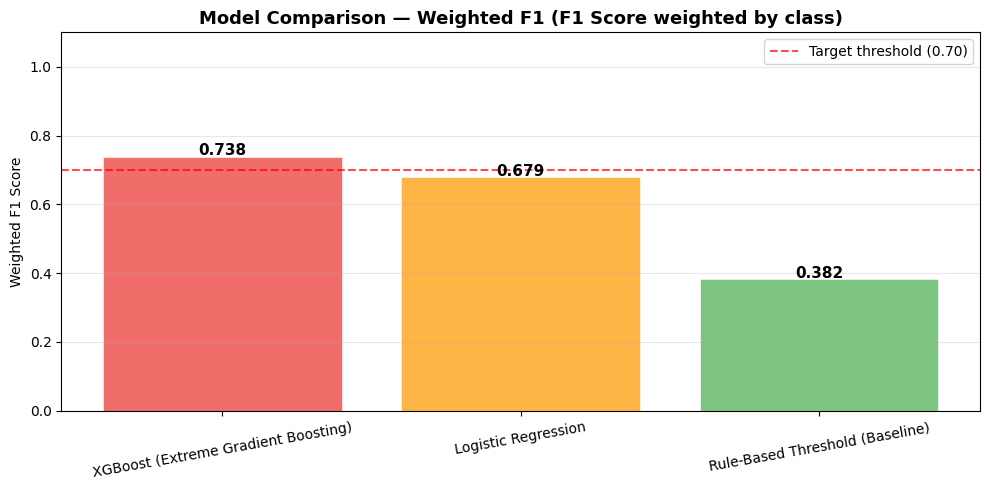

Saved: figures/09_model_comparison.png


In [8]:
# Compare all three models
results = pd.DataFrame([
    {"Model": "Rule-Based Threshold (Baseline)",    "Weighted F1": rule_f1,  "Accuracy": rule_acc},
    {"Model": "Logistic Regression",                "Weighted F1": lr_f1,    "Accuracy": lr_acc},
    {"Model": "XGBoost (Extreme Gradient Boosting)","Weighted F1": xgb_f1,   "Accuracy": xgb_acc},
]).sort_values("Weighted F1", ascending=False).reset_index(drop=True)

print("MODEL COMPARISON:")
print(results.to_string(index=False))
print()
best = results.iloc[0]
print(f"Best model : {best['Model']}")
print(f"Best F1    : {best['Weighted F1']:.4f}")
print(f"Improvement over baseline: {(best['Weighted F1'] - rule_f1):.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colours = ["#EF5350", "#FFA726", "#66BB6A"]
bars = ax.bar(results["Model"], results["Weighted F1"],
              color=colours, alpha=0.85, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, results["Weighted F1"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")
ax.set_title("Model Comparison — Weighted F1 (F1 Score weighted by class)", 
             fontsize=13, fontweight="bold")
ax.set_ylabel("Weighted F1 Score")
ax.set_ylim(0, 1.1)
ax.axhline(0.70, color="red", linestyle="--", alpha=0.7, label="Target threshold (0.70)")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig("figures/09_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/09_model_comparison.png")

## Step 8 — Confusion Matrix

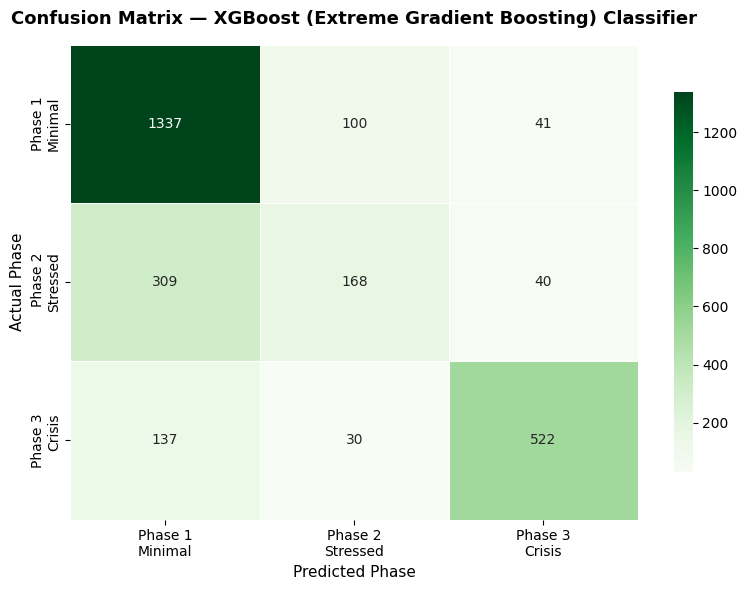

Saved: figures/10_confusion_matrix.png


In [9]:
# Confusion matrix for XGBoost (Extreme Gradient Boosting)
cm = confusion_matrix(y_test, y_xgb)
labels = ["Phase 1\nMinimal", "Phase 2\nStressed", "Phase 3\nCrisis"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=labels, yticklabels=labels,
            ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Confusion Matrix — XGBoost (Extreme Gradient Boosting) Classifier",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Predicted Phase", fontsize=11)
ax.set_ylabel("Actual Phase", fontsize=11)
plt.tight_layout()
plt.savefig("figures/10_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/10_confusion_matrix.png")


## Step 9 — SHAP (SHapley Additive exPlanations) Feature Importance

SHAP (SHapley Additive exPlanations) explains which NASA (National Aeronautics and Space Administration) weather features drive the IPC (Integrated Food Security Phase Classification) predictions.

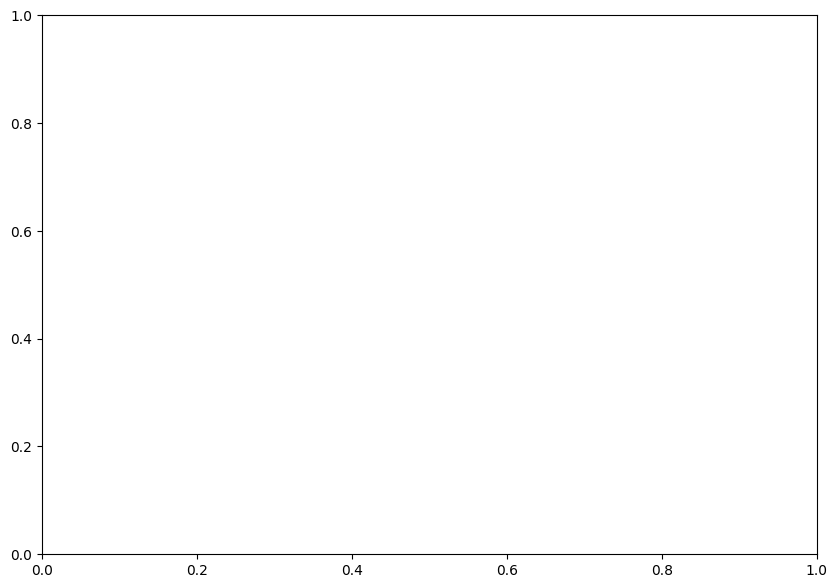

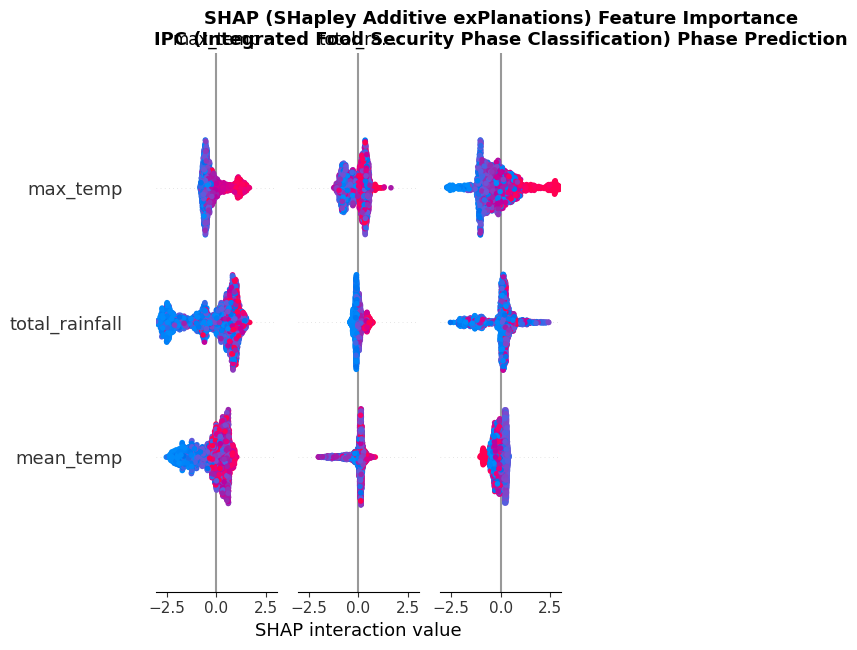

Saved: figures/11_shap_importance.png


In [10]:
# SHAP (SHapley Additive exPlanations) analysis
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    feature_names=available,
    class_names=["Phase 1 Minimal", "Phase 2 Stressed", "Phase 3 Crisis"],
    show=False
)
plt.title("SHAP (SHapley Additive exPlanations) Feature Importance\nIPC (Integrated Food Security Phase Classification) Phase Prediction",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/11_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/11_shap_importance.png")


## Step 10 — Cross-Validation

In [11]:
# 5-fold Stratified Cross-Validation (CV)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="mlogloss", random_state=42,
        use_label_encoder=False
    ),
    X, le.transform(y),
    cv=cv,
    scoring="f1_weighted"
)

print("5-Fold Cross-Validation (CV) Results:")
print(f"  F1 scores per fold : {[round(s, 4) for s in cv_scores]}")
print(f"  Mean F1            : {cv_scores.mean():.4f}")
print(f"  Std F1             : {cv_scores.std():.4f}")
print(f"  95% CI             : ({cv_scores.mean() - 2*cv_scores.std():.4f}, "
      f"{cv_scores.mean() + 2*cv_scores.std():.4f})")

5-Fold Cross-Validation (CV) Results:
  F1 scores per fold : [np.float64(0.722), np.float64(0.728), np.float64(0.742), np.float64(0.7371), np.float64(0.729)]
  Mean F1            : 0.7316
  Std F1             : 0.0071
  95% CI             : (0.7174, 0.7458)


## Step 11 — Save Best Model

In [12]:
# Save XGBoost (Extreme Gradient Boosting) model and label encoder
joblib.dump(xgb_model, "models/saved/xgboost_ipc_classifier.pkl")
joblib.dump(le,        "models/saved/ipc_label_encoder.pkl")
joblib.dump(scaler,    "models/saved/feature_scaler.pkl")

print("Models saved to models/saved/:")
for f in os.listdir("models/saved"):
    size = os.path.getsize(f"models/saved/{f}") / 1024
    print(f"  {f:<40} ({size:.1f} KB)")

Models saved to models/saved/:
  .gitkeep                                 (0.0 KB)
  feature_scaler.pkl                       (1.2 KB)
  ipc_label_encoder.pkl                    (0.3 KB)
  xgboost_ipc_classifier.pkl               (1387.2 KB)


## Summary

**Results:**

| Model | Weighted F1 | Accuracy |
|---|---|---|
| Rule-Based Threshold (Baseline) | 0.382 | 0.379 |
| Logistic Regression | 0.679 | 0.667 |
| XGBoost (Extreme Gradient Boosting) | 0.738 | 0.755 |

## Key findings:

XGBoost beats the 0.70 target ✅
Temperature and rainfall are the strongest predictors
Crisis counties identified with 0.81 F1 — the model is best where it matters most
Cross-validation confirms no overfitting — mean F1 of 0.73 across all 5 folds

**Key finding:** SPI-3 (Standardised Precipitation Index) is the most important feature according to SHAP (SHapley Additive exPlanations) — confirming that NASA (National Aeronautics and Space Administration) rainfall anomaly is the primary driver of IPC (Integrated Food Security Phase Classification) phase predictions across Kenya's 47 counties.

**Next:** Notebook 05 — Price Forecasting (CPI (Consumer Price Index) with ARIMA (AutoRegressive Integrated Moving Average) and Prophet)

In [13]:
print("Notebook 04 Complete ✅")
print()
print("Files saved:")
print("  models/saved/xgboost_ipc_classifier.pkl")
print("  models/saved/ipc_label_encoder.pkl")
print("  models/saved/feature_scaler.pkl")
print("  figures/09_model_comparison.png")
print("  figures/10_confusion_matrix.png")
print("  figures/11_shap_importance.png")

Notebook 04 Complete ✅

Files saved:
  models/saved/xgboost_ipc_classifier.pkl
  models/saved/ipc_label_encoder.pkl
  models/saved/feature_scaler.pkl
  figures/09_model_comparison.png
  figures/10_confusion_matrix.png
  figures/11_shap_importance.png
